In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/email.csv')

In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5573, 2)

## 1. Data Cleaning

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [ ]:
df['Category'] = encoder.fit_transform(df['Category'])

In [ ]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['Category'].value_counts()

,count
Category,
0,4825
1,747
2,1


In [ ]:
df = df.drop(df[df['Category'] == 2].index)

In [ ]:
# Check Missing Values

df.isnull().sum()

,0
Category,0
Message,0


In [ ]:
# Check Duplicate Values
df.duplicated().sum()


np.int64(415)

## 2. EDA

<Axes: xlabel='Category', ylabel='count'>

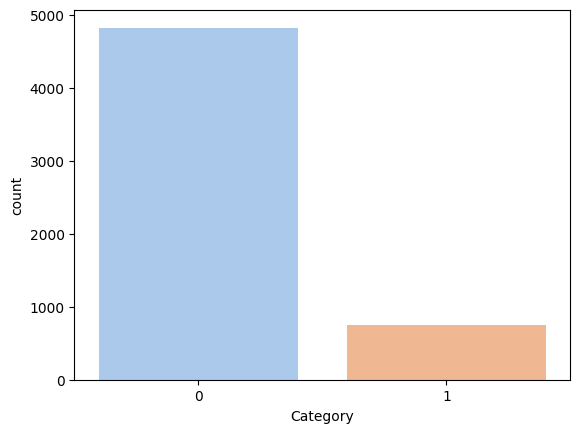

In [ ]:
sns.countplot(
    data = df,
    x = 'Category',
    palette = 'pastel'
)

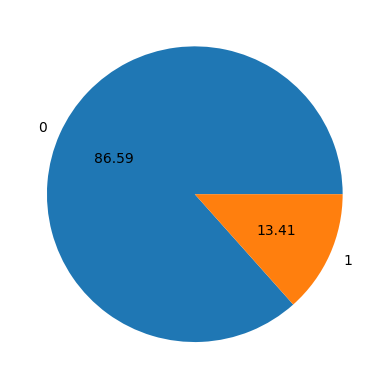


 Data is imbalcaned


In [ ]:
plt.pie(
    df.Category.value_counts(),
    labels=df.Category.value_counts().index,
    autopct="%.2f"
    )
plt.show()

print('\n Data is imbalcaned')

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Number of charecter in one row
df['Num_charecter'] = df['Message'].apply(len)

In [ ]:
# Number of word

df['Num_word']= df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df['Num_sentance'] = df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,Category,Message,Num_charecter,Num_word,Num_sentance
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['Num_charecter','Num_word','Num_sentance']].describe()

,Num_charecter,Num_word,Num_sentance
count,5572.000000,5572.000000,5572.000000
mean,80.368988,18.826992,2.004666
std,59.926946,13.853616,1.539516
min,2.000000,1.000000,1.000000
25%,35.750000,9.000000,1.000000
50%,61.000000,15.000000,2.000000
75%,122.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['Category'] == 0][['Num_charecter','Num_word','Num_sentance']].describe()

,Num_charecter,Num_word,Num_sentance
count,4825.000000,4825.000000,4825.000000
mean,71.448290,17.425699,1.846010
std,58.434864,14.118631,1.475377
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,93.000000,23.000000,2.000000
max,910.000000,220.000000,38.000000


<Axes: xlabel='Num_charecter', ylabel='Count'>

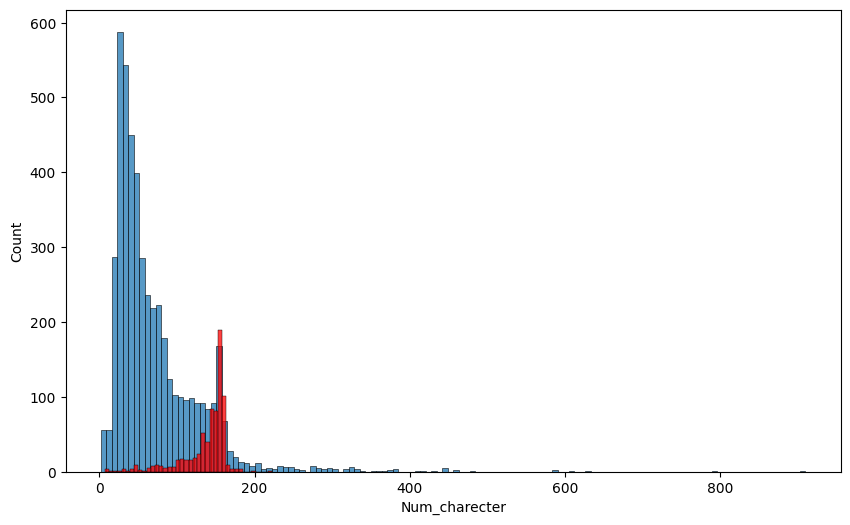

In [ ]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['Category'] == 0]['Num_charecter'])
sns.histplot(df[df['Category'] == 1]['Num_charecter'],color = 'red')

<Axes: xlabel='Num_word', ylabel='Count'>

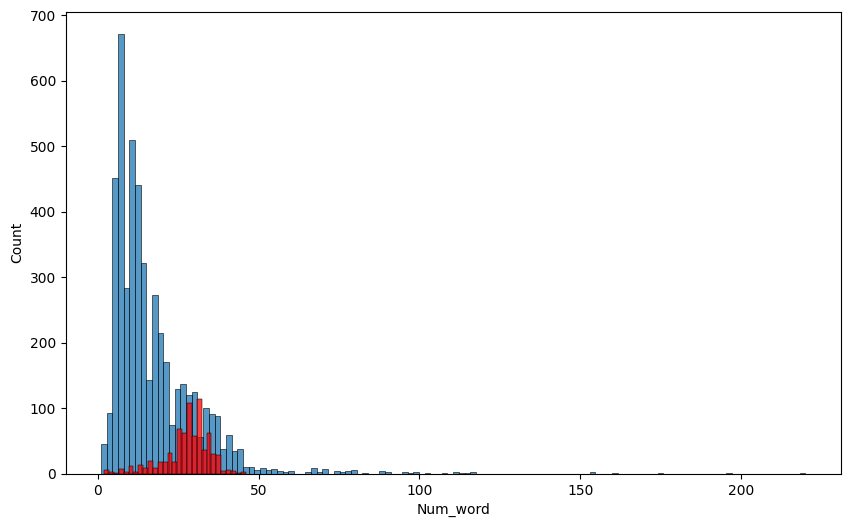

In [ ]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['Category'] == 0]['Num_word'])
sns.histplot(df[df['Category'] == 1]['Num_word'],color = 'red')

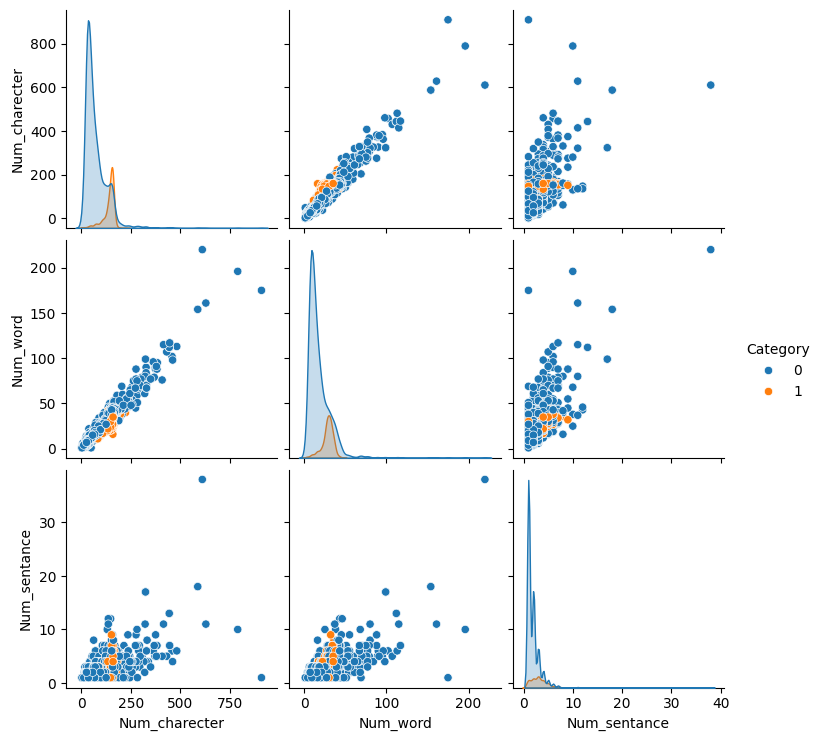

In [ ]:
sns.pairplot(df,hue = 'Category')

<Axes: >

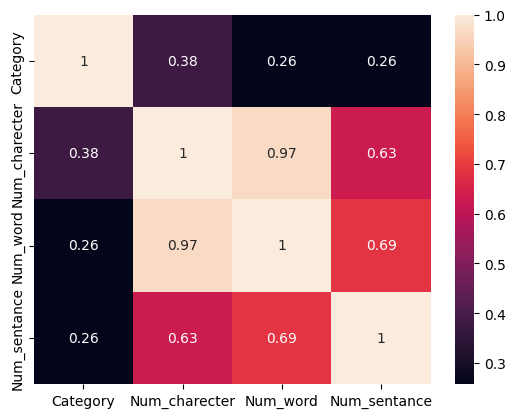

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot = True)

## 3. Data preprocessing


*   Lower Case
*   Tokenization
*   Removing Special Charecter
*   Removing stop wards and punctuation
*   Stemming



In [ ]:
def data_preocessing(Message):
    Message = Message.lower()
    Message = nltk.word_tokenize(Message)
    y = []
    for i in Message:
        if i.isalnum():
            y.append(i)

    return y

In [ ]:
data_preocessing('hello how AEE  && ## you')

['hello', 'how', 'aee', 'you']

# 4. Model Buliding

# 5. Evaluation

# 6. Improvement

# 7. Making Website